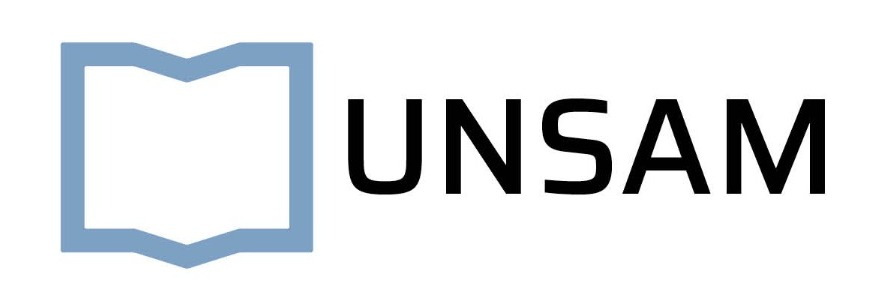

#### Análisis y Procesamiento de Señales

# TS3: Analisis de Fourier
#### Alumno: Sebastián Roca Garza



## Introducción
En este trabajo se analiza el comportamiento de la Transformada Discreta de Fourier (DFT) sobre señales senoidales continuas en el tiempo cuando son muestreadas y acotadas en una ventana finita. Se estudiará el fenómeno de fuga espectral (spectral leakage), la conservación de la potencia a través de la Identidad de Parseval y la técnica de zero padding como herramienta de interpolación en el dominio de la frecuencia.


# Codigo y Análisis


### Parámetros generales
* Frecuencia de muestreo $f_S$: $1000 \text{ Hz}$
* Número de muestras $N$: $1000$
* Resolución espectral base $\Delta f = f_S / N$ =  $1 \text{ Hz}$
* Amplitud $A_0$: $\sqrt{2}$ (garantiza potencia promedio unitaria)

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros generales
N = 1000
fs = 1000
ts = 1/fs
n = np.arange(N)
a0 = np.sqrt(2)

# Valores k0
k_valores = [N/4, N/4 + 0.25, N/4 + 0.5]


# Vector de bins hasta Nyquist 
bins = np.arange(0, N // 2) * (fs / N)

### a) Gráficos de Densidad Espectral de Potencia (PSD)

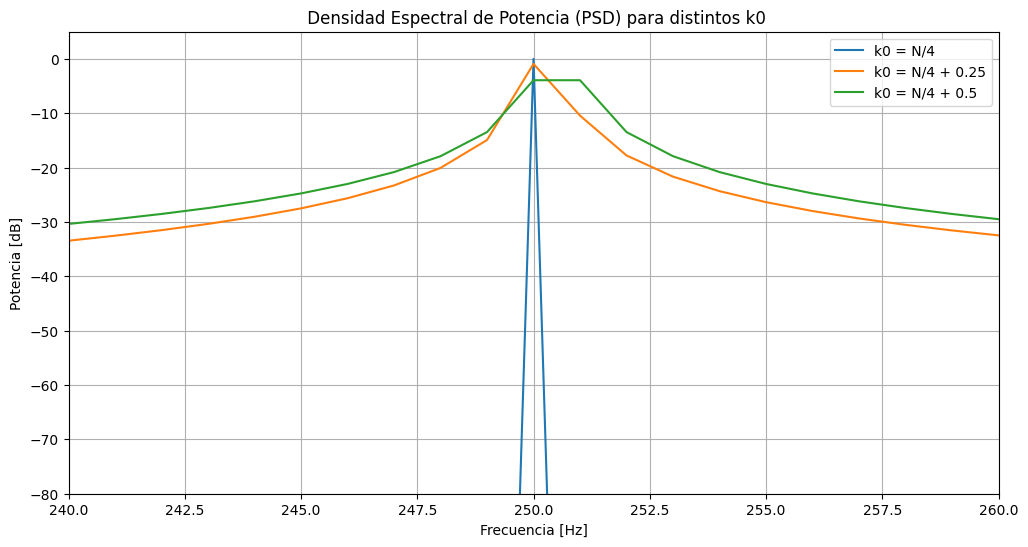

In [6]:
plt.figure(figsize=(12, 6))

psd_list = []
x_list = []
x_fft_list = []
labels = ["k0 = N/4", "k0 = N/4 + 0.25", "k0 = N/4 + 0.5"]

for k0, label in zip(k_valores, labels):
    f0 = k0 * (fs / N)
    x = a0 * np.sin(2 * np.pi * f0 * n * ts)
    
    # FFT de la señal
    x_fft = (1 / N) * np.fft.fft(x)
    
    # PSD 
    x_fft_spect = 2 * (np.abs(x_fft[0:(N // 2)])**2)
    x_spect_db = 10 * np.log10(x_fft_spect)
    
    # Guaro para putnos b y c
    psd_list.append(x_spect_db)
    x_list.append(x)
    x_fft_list.append(x_fft)
    
    plt.plot(bins, x_spect_db, label=label)

plt.title(" Densidad Espectral de Potencia (PSD) para distintos k0")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia [dB]")
plt.xlim([240, 260]) # Zoom en f0 = 250 Hz
plt.ylim([-80, 5])
plt.grid(True)
plt.legend()
plt.show()

A partir del gráfico se ve una diferencia visual que ocurre porque la DFT no mide un espectro continuo, sino muestras discretas provenientes de la multiplicación temporal entre una senoidal infinita y una ventana rectangular (donde su respuesta en frecuencia tiene forma de $\text{sinc}$).
Se ve que cuando la señal está perfectamente sintonizada en $k_0 = N/4$, las muestras de la DFT caen con exactitud sobre los ceros de los lóbulos secundarios de la $\text{sinc}$, ocultando por completo el leakage. Por el contrario, en los casos desintonizados, las muestras caen sobre el "cuerpo" de los lóbulos, haciendo visible el $\text desparramo\ espectral$.

### b) Verificación de Potencia y Teorema de Parseval

In [9]:
print("--- VERIFICACIÓN DE PARSEVAL ---")

for k0, x, x_fft in zip(k_valores, x_list, x_fft_list):
    # Potencia en el dominio del tiempo
    P_t = np.mean(x**2)
    
    # Potencia en el dominio de la frecuencia con parseval Parseval
    P_frec = np.sum(np.abs(x_fft)**2)
    
    print(f"k0 = {k0:6.2f} | Potencia en el dominio de tiempo: {P_t:.6f} | Potencia en el domínio de frecuencia (Parseval): {P_frec:.6f}")

--- VERIFICACIÓN DE PARSEVAL ---
k0 = 250.00 | Potencia en el dominio de tiempo: 1.000000 | Potencia en el domínio de frecuencia (Parseval): 1.000000
k0 = 250.25 | Potencia en el dominio de tiempo: 0.999000 | Potencia en el domínio de frecuencia (Parseval): 0.999000
k0 = 250.50 | Potencia en el dominio de tiempo: 1.000000 | Potencia en el domínio de frecuencia (Parseval): 1.000000



Los resultados numéricos demuestran el cumplimiento de la identidad de Parseval, ya que tanto la potencia calculada en el dominio del tiempo ($P = \frac{1}{N}\sum \vert x[n] \vert^2$) como la obtenida al integrar la PSD en el dominio de la frecuencia ($P = \sum \vert X[k] \vert^2$) resultan idénticas a 1 para los tres escenarios. Esto confirma que, físicamente, la energía total transportada por la senoidal se mantiene constante ($P=1$), a pesar del cambio de apenas unos pocos Hertz que desalinea la frecuencia respecto a los bins de la DFT, alterando el espectro.

### c) Análisis con Zero Padding ($9 * N$ ceros)

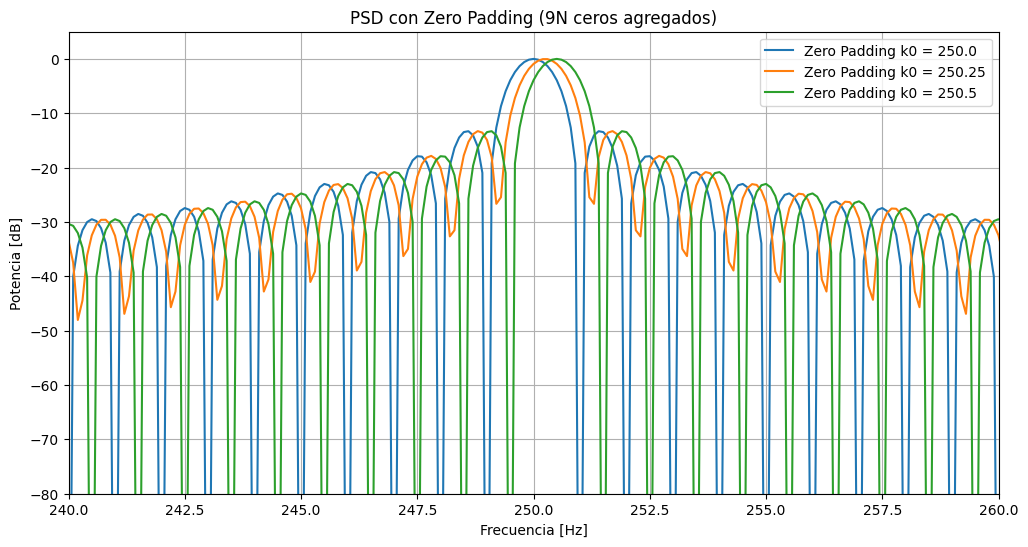

In [10]:
N_zero_pad = 9 * N
N_total = N + N_zero_pad # 10000 muestras

bins_pad = np.arange(0, N_total // 2) * (fs / N_total)

plt.figure(figsize=(12, 6))

for k0, x in zip(k_values, x_list):
    # Concatenación de ceros al final
    x_padded = np.concatenate((x, np.zeros(N_zero_pad)))
    
    # FFT manteniendo la escala / N (ya que la energía está contenida en las primeras N muestras)
    x_fft_pad = (1 / N) * np.fft.fft(x_padded)
    
    # PSD con zero padding
    x_fft_spect_pad = 2 * (np.abs(x_fft_pad[0:(N_total // 2)])**2)
    x_spect_pad_db = 10 * np.log10(x_fft_spect_pad + 1e-15)
    
    plt.plot(bins_pad, x_spect_pad_db, label=f"Zero Padding k0 = {k0}")

plt.title("PSD con Zero Padding (9N ceros agregados)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia [dB]")
plt.xlim([240, 260]) # Mismo zoom para comparar
plt.ylim([-80, 5])
plt.grid(True)
plt.legend()
plt.show()

Al aplicar la técnica de zero padding e incrementar el vector a $N_{\text{total}} = 10000$ muestras, la resolución espectral de cálculo pasa a ser $\Delta f = f_S / N_{\text{total}} = 0.1 \text{ Hz}$. Esto genera una diez veces bins, por ende es más denso el espectro, suaviza las curvas y revela la verdadera envolvente continua tipo $\text{sinc}$ de la ventana. Gracias a esta mayor densidad de puntos, incluso el caso perfectamente sintonizado ($k_0 = N/4$) muestra ahora los lóbulos laterales, lo que confirma que el spectral leakage no es un problema exclusivo de las frecuencias desintonizadas, sino una consecuencia directa del tipo de ventana de observación en el tiempo. Finalmente, esta experiencia pone en evidencia la diferencia entre resolución física y cosmética: agregar ceros no incrementa el poder de resolución física para separar dos componentes frecuenciales cercanas, dado que el ancho del lóbulo principal sigue dependiendo exclusivamente del número original de muestras $N$. Por lo tanto, el zero padding debe entenderse estrictamente como una técnica de interpolación digital en frecuencia que mejora la representación visual de la señal, pero sin aportar información nueva.

# Conclusión


En conclusión, el análisis demuestra que el truncamiento temporal de una señal mediante una ventana de observación finita genera inevitablemente el fenómeno de fuga o derrame espectral (spectral leakage). Aunque variaciones mínimas en la frecuencia desalineen la señal de los bins de la DFT y alteren drásticamente la visualización del espectro, la verificación de la Identidad de Parseval nos asegura que la potencia total se conserva de manera estricta en todos los escenarios, limitándose el efecto visual a una simple redistribución de la energía entre los distintos bins. Por su parte, la aplicación de la técnica de zero padding evidencia que estos lóbulos laterales siempre están presentes; al rellenar con ceros la señal no estamos añadiendo nueva información ni mejorando la resolución espectral física para separar componentes cercanas, sino realizando una interpolación digital. Esta interpolación densifica el muestreo en frecuencia ($\Delta f$), lo que revela la verdadera naturaleza continua de la envolvente espectral y desmiente la ilusión de un espectro "perfecto" o sin fugas en las frecuencias sintonizadas.